In [2]:
import torch
from utils import solve_riccati
import numpy as np
from network import PhiNetwork, ScoreNetwork
from utils import batched_jacobian
import matplotlib.pyplot as plt

In [4]:
phi_net = ScoreNetwork(input_dim=2+1, out_dim=2, hidden_dim=32)
phi_net.load_state_dict(torch.load('network/phi_network_ip_bsde_nl0.5_v3.pth'))

/var/folders/pd/hp6m3j2j5v9bd6w64h7wl3rm0000gn/T/ipykernel_61302/3959161453.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  phi_net.load_state_dict(torch.load('network/p

<All keys matched successfully>

In [3]:
T = 4.0  # End time
n = 2    # Dimension of state space
m = 1    # Dimension of Brownian motion
N = 10000 # Number of training samples
dt = 0.05
steps = int(T/dt)
noise_level = 0.5

In [5]:
def f(x):
    """
    Drift function of X_t for a nonlinear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
    Returns:
        torch.Tensor: Drift vector. Shape (N, n)
    """
    df1 = x[:, 1]
    df2 = torch.sin(x[:, 0]) - 0.01 * x[:, 1]
    df = torch.stack((df1, df2), dim=1)
    return df


def g(x):
    """
    Diffusion function of X_t for a nonlinear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
    Returns:
        torch.Tensor: Diffusion matrix. Shape (N, n, m)
    """
    B = torch.tensor([[0.0], [1.0]]) * noise_level
    B = B.unsqueeze(0).repeat(x.shape[0], 1, 1)
    return B

def lf(x):
    """
    Terminal cost function for a linear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
    Returns:
        torch.Tensor: Terminal cost. Shape (N,)
    """
    # Q_f = torch.tensor([[1.0, 0.0], [0.0, 1.0]])
    # return 0.5 * ((x @ Q_f) * x).sum(dim=1)
    return 0.5 * x[:,1] * x[:,1] + 1 - torch.cos(x[:,0])

In [6]:
from utils import rollout, noise

iteration    0 | autograd loss 24578.9 | phi loss 24578.9
iteration  500 | autograd loss 22779.4 | phi loss 19412.8
iteration 1000 | autograd loss 21884.9 | phi loss 17338.3
iteration 1500 | autograd loss 21288.9 | phi loss 16581.9
iteration 2000 | autograd loss 20510.5 | phi loss 15786.5
iteration 2500 | autograd loss 19893.5 | phi loss 15238.4
iteration 3000 | autograd loss 19626.2 | phi loss 15129.5
iteration 3500 | autograd loss 19457.2 | phi loss 15088.5
iteration 4000 | autograd loss 19307.7 | phi loss 15201.7
iteration 4500 | autograd loss 18631.6 | phi loss 14921
iteration 5000 | autograd loss 18444.2 | phi loss 14958
iteration 5500 | autograd loss 18121.7 | phi loss 14829.4
iteration 6000 | autograd loss 18329.1 | phi loss 15339.7
iteration 6500 | autograd loss 17761.1 | phi loss 14859.6
iteration 7000 | autograd loss 17601.2 | phi loss 14931.4
iteration 7500 | autograd loss 17359.2 | phi loss 14880.9
iteration 8000 | autograd loss 17302.3 | phi loss 14992.2
iteration 8500 | a

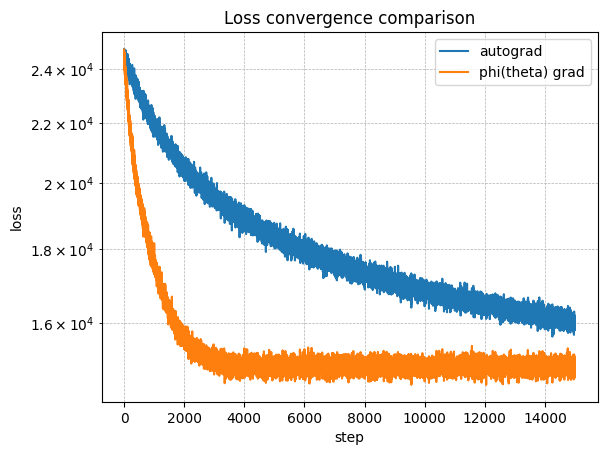

In [19]:
theta0 = torch.randn((N, n))

theta_auto = theta0.clone().detach().requires_grad_(True)
theta_phi  = theta0.clone().detach().requires_grad_(True)  # requires_grad can stay True; we won't call backward()

opt_auto = torch.optim.Adam([theta_auto], lr=1e-3)
opt_phi  = torch.optim.Adam([theta_phi],  lr=1e-3)

loss_hist_auto = []
loss_hist_phi  = []
theta_hist_auto = []
theta_hist_phi  = []
theta_hist_auto.append(theta_auto.detach().clone())
theta_hist_phi.append(theta_phi.detach().clone())
for i in range(15000):
    W_f = torch.zeros((steps+1, N, m))# forward noise

    for noise_step in range(steps+1):
        W_f[noise_step, :, :] = noise(dt, N, m)
    # ======== Method A: autograd ========
    opt_auto.zero_grad(set_to_none=True)

    # compute loss (keep exactly same code path)
    xT_auto = rollout(f, g, T, dt, theta_auto, W_f)[-1]
    loss_auto = lf(xT_auto).sum(dim=0)  # your original loss
    loss_auto.backward()
    opt_auto.step()

    # ======== Method B: custom phi gradient ========
    opt_phi.zero_grad(set_to_none=True)

    # compute loss for logging only (optional but useful)
    # If rollout is expensive and you only care about update, you can skip this forward.
    with torch.no_grad():
        xT_phi = rollout(f, g, T, dt, theta_phi, W_f)[-1]
        loss_phi = lf(xT_phi).sum(dim=0)

    # apply your gradient estimator
    # IMPORTANT: optimizer expects theta_phi.grad to be a tensor on same device/dtype
    with torch.no_grad():
        ghat = phi_net(theta_phi, torch.tensor(0.0).repeat(theta_phi.shape[0], 1))  # shape (N, n)
        theta_phi.grad = ghat.detach()
    opt_phi.step()

    # ---- log ----
    loss_hist_auto.append(loss_auto.detach().item() if loss_auto.numel()==1 else loss_auto.detach().sum().item())
    loss_hist_phi.append(loss_phi.detach().item()  if loss_phi.numel()==1  else loss_phi.detach().sum().item())

    theta_hist_auto.append(theta_auto.detach().clone())
    theta_hist_phi.append(theta_phi.detach().clone())

    # optional: print occasionally
    if i % max(1, 500) == 0:
        print(f"iteration {i:4d} | autograd loss {loss_hist_auto[-1]:.6g} | phi loss {loss_hist_phi[-1]:.6g}")

# ---- final report ----
print("\nFinal:")
print(f"autograd: loss={loss_hist_auto[-1]:.6g}")
print(f"phi     : loss={loss_hist_phi[-1]:.6g}")

# ---- plot ----
plt.figure()
plt.plot(loss_hist_auto, label="autograd")
plt.plot(loss_hist_phi,  label="phi(theta) grad")
plt.yscale("log")  # often helpful; remove if you prefer linear
plt.xlabel("step")
plt.ylabel("loss")
plt.title("Loss convergence comparison")
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()

Text(0.5, 1.0, 'Optimal theta comparison')

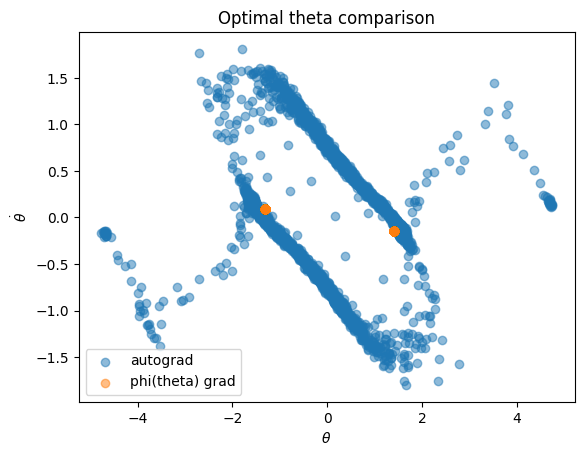

In [20]:
## plot of optimal theta
plt.figure()
plt.scatter(theta_auto.detach().numpy()[:,0], theta_auto.detach().numpy()[:,1], label="autograd", alpha=0.5)
plt.scatter(theta_phi.detach().numpy()[:,0], theta_phi.detach().numpy()[:,1], label="phi(theta) grad", alpha=0.5)
plt.xlabel(r"$\theta$")
plt.ylabel(r"$\dot{\theta}$")
plt.legend()
plt.title("Optimal theta comparison")

In [21]:
theta_phi.detach().mean(dim=0), theta_auto.detach().mean(dim=0)

(tensor([-0.0081, -0.0227]), tensor([-0.0086,  0.0004]))

In [22]:
theta_phi.detach().std(dim=0), theta_auto.detach().std(dim=0)

(tensor([1.3623, 0.1154]), tensor([1.4803, 0.3976]))

In [23]:
randindex = np.random.randint(0, theta_phi.shape[0], size=50) # generate 50 random index
theta_phi.detach()[randindex,0]

tensor([ 1.4198,  1.4197,  1.4198,  1.4198,  1.4198,  1.4198, -1.3077,  1.4198,
         1.4198, -1.3077,  1.4198, -1.3077,  1.4198, -1.3077,  1.4198,  1.4198,
        -1.3077, -1.3077,  1.4198,  1.4198, -1.3077,  1.4198, -1.3077, -1.3077,
        -1.3077, -1.3077, -1.3077, -1.3077, -1.3077, -1.3077, -1.3077, -1.3077,
         1.4198,  1.4198, -1.3077,  1.4198,  1.4198, -1.3077,  1.4198, -1.3077,
        -1.3077,  1.4198,  1.4198, -1.3077,  1.4198, -1.3077,  1.4198, -1.3077,
        -1.3077, -1.3077])

In [24]:
final_traj_phi = rollout(f, g, T, dt, theta_phi, W_f)
final_traj_auto = rollout(f, g, T, dt, theta_auto, W_f)

In [25]:
final_traj_phi.shape

torch.Size([81, 10000, 2])

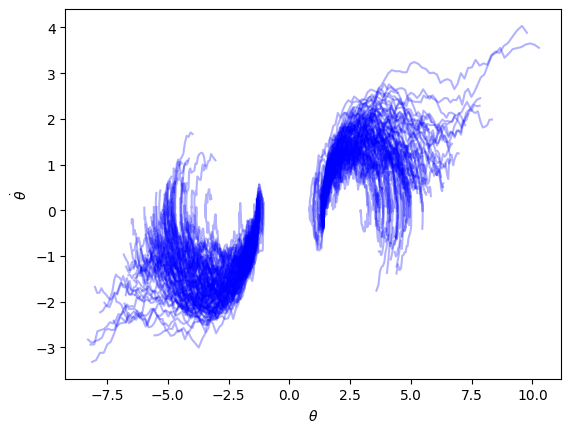

In [26]:
plt.figure()
for sample_idx in range(200):
    plt.plot(final_traj_phi[:, sample_idx, 0].detach().numpy(), final_traj_phi[:, sample_idx, 1].detach().numpy(), color='blue', alpha=0.3)
    # plt.plot(final_traj_auto[:, sample_idx, 0].detach().numpy(), final_traj_auto[:, sample_idx, 1].detach().numpy(), color='orange', alpha=0.3)
plt.xlabel(r"$\theta$")
plt.ylabel(r"$\dot{\theta}$")
# plt.title("Sample trajectories with phi(theta) grad")
plt.show()

In [27]:
theta_hist_phi = torch.stack(theta_hist_phi, dim=0)  # shape (steps, N, n)
theta_hist_auto = torch.stack(theta_hist_auto, dim=0)  # shape (steps, N, n)

In [34]:
torch.save(theta_hist_phi, 'data/theta_hist_phi_nl0.5_v3.pt')
torch.save(theta_hist_auto, 'data/theta_hist_auto_nl0.5_v3.pt')

In [41]:
theta_hist_phi = torch.load('data/theta_hist_phi_nl0.5_v3.pt')
theta_hist_auto = torch.load('data/theta_hist_auto_nl0.5_v3.pt')

/var/folders/pd/hp6m3j2j5v9bd6w64h7wl3rm0000gn/T/ipykernel_61302/2209213816.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  theta_hist_phi = torch.load('data/theta_hist_

In [42]:
theta_hist_phi_part = theta_hist_phi[:5000, :100, :]  # shape (steps, N/2, n)
theta_hist_auto_part = theta_hist_auto[:5000, :100, :]  # shape (steps, N/2, n)

In [73]:
exp_num = 10000
# loss_phi = torch.zeros((theta_hist_phi.shape[0], theta_hist_phi.shape[1], 1))
# loss_auto = torch.zeros((theta_hist_auto.shape[0], theta_hist_auto.shape[1], 1))

In [74]:
# vectorized computation
theta_hist_phi_vec = theta_hist_phi_part.reshape(-1, n)  # shape (steps*N, n)
theta_hist_auto_vec = theta_hist_auto_part.reshape(-1, n)  # shape (steps*N, n)

In [75]:
loss_phi_vec = torch.zeros((theta_hist_phi_vec.shape[0], 1))
loss_auto_vec = torch.zeros((theta_hist_auto_vec.shape[0], 1))
for exp_i in range(exp_num):
    
        # generate noise
    # W_f = torch.zeros((steps+1, theta_hist_phi_vec.shape[0], m))# forward noise
    # for noise_step in range(steps+1):
    #     # print(noise_step)
    #     W_f[noise_step, :, :] = noise(dt, theta_hist_phi_vec.shape[0], m)
    W_f = torch.randn(steps + 1, theta_hist_phi_vec.shape[0], m) * torch.sqrt(torch.tensor(dt))
    
    loss_phi_vec += lf(rollout(f, g, T, dt, theta_hist_phi_vec, W_f)[-1]).unsqueeze(-1) # shape (N, 1)
    loss_auto_vec += lf(rollout(f, g, T, dt, theta_hist_auto_vec, W_f)[-1]).unsqueeze(-1) # shape (N, 1)
    

    if exp_i % 50 == 0:
        print(f"experiment {exp_i}/{exp_num} done.")

loss_phi_vec /= exp_num
loss_auto_vec /= exp_num

experiment 0/10000 done.
experiment 50/10000 done.
experiment 100/10000 done.
experiment 150/10000 done.
experiment 200/10000 done.
experiment 250/10000 done.
experiment 300/10000 done.
experiment 350/10000 done.
experiment 400/10000 done.
experiment 450/10000 done.
experiment 500/10000 done.
experiment 550/10000 done.
experiment 600/10000 done.
experiment 650/10000 done.
experiment 700/10000 done.
experiment 750/10000 done.
experiment 800/10000 done.
experiment 850/10000 done.
experiment 900/10000 done.
experiment 950/10000 done.
experiment 1000/10000 done.
experiment 1050/10000 done.
experiment 1100/10000 done.
experiment 1150/10000 done.
experiment 1200/10000 done.
experiment 1250/10000 done.
experiment 1300/10000 done.
experiment 1350/10000 done.
experiment 1400/10000 done.
experiment 1450/10000 done.
experiment 1500/10000 done.
experiment 1550/10000 done.
experiment 1600/10000 done.
experiment 1650/10000 done.
experiment 1700/10000 done.
experiment 1750/10000 done.
experiment 1800

In [76]:
loss_phi = loss_phi_vec.reshape(theta_hist_phi_part.shape[0], theta_hist_phi_part.shape[1], 1)
loss_auto = loss_auto_vec.reshape(theta_hist_auto_part.shape[0], theta_hist_auto_part.shape[1], 1)

In [77]:
torch.save(loss_phi, f"data/{exp_num}ave_phi_loss.pt")
torch.save(loss_auto, f"data/{exp_num}ave_auto_loss.pt")

In [78]:
loss_phi.shape, loss_auto.shape

(torch.Size([5000, 100, 1]), torch.Size([5000, 100, 1]))

In [79]:
# torch.save(loss_phi, 'data/loss_phi_nl0.5_v3_500theta_500rollout.pt')
# torch.save(loss_auto, 'data/loss_auto_nl0.5_v3_500theta_500rollout.pt')

In [80]:
mean_loss_phi = loss_phi.mean(dim=1).squeeze().numpy()
mean_loss_auto = loss_auto.mean(dim=1).squeeze().numpy()
std_loss_phi = loss_phi.std(dim=1).squeeze().numpy()
std_loss_auto = loss_auto.std(dim=1).squeeze().numpy()

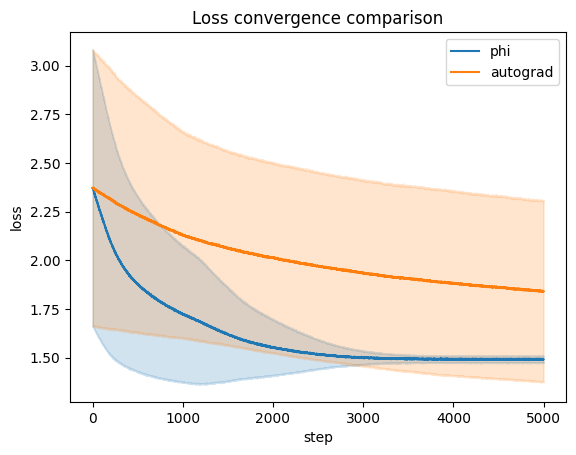

In [81]:
plt.figure()
plt.plot(loss_phi.mean(dim=1).squeeze().numpy(), label="phi", color="C0")
plt.plot(loss_auto.mean(dim=1).squeeze().numpy(), label="autograd", color="C1")
plt.fill_between(range(len(mean_loss_phi)), mean_loss_phi - std_loss_phi, mean_loss_phi + std_loss_phi, alpha=0.2, color="C0")
plt.fill_between(range(len(mean_loss_auto)), mean_loss_auto - std_loss_auto, mean_loss_auto + std_loss_auto, alpha=0.2, color="C1")
# plt.yscale("log")  # often helpful; remove if you prefer linear
plt.xlabel("step")
plt.ylabel("loss")
plt.title("Loss convergence comparison")
plt.legend()


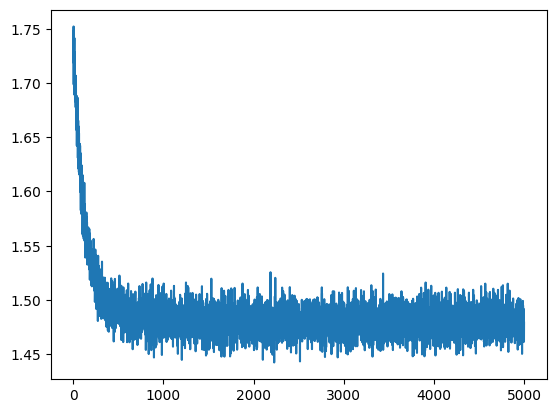

In [82]:
plt.figure()
plt.plot(loss_phi[:,0,:])